In [3]:
from datasets import load_dataset

ds = load_dataset("fancyzhx/amazon_polarity")

In [4]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 3600000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 400000
    })
})


In [5]:
ds["train"]= ds["train"].shuffle(seed=42).select(range(500000))
ds["test"]= ds["test"].shuffle(seed=42).select(range(100000))

In [6]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 500000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 100000
    })
})


In [7]:
def combine_text(example):
    return {
        "text": example["title"] + " " + example["content"]
    }
    
ds= ds.map(combine_text)

In [8]:
ds["train"][2]

{'label': 1,
 'title': 'Spaetzle Noodles',
 'content': "This type of spaetzle maker is easier to manuveur than the old press kind and much easier on the hands. The difference is that this new spaetzle maker makes smaller noodles than the old. It is great for us elderly that don't have much strength left.",
 'text': "Spaetzle Noodles This type of spaetzle maker is easier to manuveur than the old press kind and much easier on the hands. The difference is that this new spaetzle maker makes smaller noodles than the old. It is great for us elderly that don't have much strength left."}

In [9]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content', 'text'],
        num_rows: 500000
    })
    test: Dataset({
        features: ['label', 'title', 'content', 'text'],
        num_rows: 100000
    })
})


In [10]:
ds["train"].column_names

['label', 'title', 'content', 'text']

In [11]:
ds["test"].column_names

['label', 'title', 'content', 'text']

In [12]:
import re

In [13]:
import pandas as pd

In [14]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]","",text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [15]:
ds = ds.map(lambda x: {"clean_text": clean_text(x["text"])})

In [16]:
ds["train"][0]

{'label': 0,
 'title': 'Anyone who likes this better than the Pekinpah is a moron.',
 'content': "All the pretty people in this film. Even the Rudy character played by Michael Madsen. This is adapted from a Jim Thompson novel for cryin' out loud! These are supposed to be marginal characters, not fashion models. Though McQueen and McGraw were attractive (but check out McQueen's crummy prison haircut) they were believable in the role. Baldwin and Bassinger seem like movie stars trying to act like hard cases. Action wise, the robbery scene in the Pekinpah version was about 100 times more exciting and suspenseful than anything in this re-make.",
 'text': "Anyone who likes this better than the Pekinpah is a moron. All the pretty people in this film. Even the Rudy character played by Michael Madsen. This is adapted from a Jim Thompson novel for cryin' out loud! These are supposed to be marginal characters, not fashion models. Though McQueen and McGraw were attractive (but check out McQueen's

In [17]:
train_df = ds["train"].to_pandas()
test_df = ds["test"].to_pandas()

In [18]:
train_df.head()

,label,title,content,text,clean_text
0,0,Anyone who likes this better than the Pekinpah...,All the pretty people in this film. Even the R...,Anyone who likes this better than the Pekinpah...,anyone who likes this better than the pekinpah...
1,0,Author seems mentally unstable,I know that Tom Robbins has a loyal following ...,Author seems mentally unstable I know that Tom...,author seems mentally unstable i know that tom...
2,1,Spaetzle Noodles,This type of spaetzle maker is easier to manuv...,Spaetzle Noodles This type of spaetzle maker i...,spaetzle noodles this type of spaetzle maker i...
3,1,Cool product until the cats lost it . . . .,My cats seemed to be amused to work for their ...,Cool product until the cats lost it . . . . My...,cool product until the cats lost it my cats se...
4,1,Works as expected,I've had no problems running this with my Dell...,Works as expected I've had no problems running...,works as expected ive had no problems running ...


In [19]:
test_df.head()

,label,title,content,text,clean_text
0,1,Damaged Product,The product works fine. I ordered the more exp...,Damaged Product The product works fine. I orde...,damaged product the product works fine i order...
1,0,A waste of time and money,This book is so useless that I feel compelled ...,A waste of time and money This book is so usel...,a waste of time and money this book is so usel...
2,0,"Scattered, Out-of-Date,",The authors attempt an ambitious goal of cover...,"Scattered, Out-of-Date, The authors attempt an...",scattered outofdate the authors attempt an amb...
3,0,Horrible Customer Service & Product,I ordered this product and did recieve then a ...,Horrible Customer Service & Product I ordered ...,horrible customer service product i ordered th...
4,0,Is the joke on me?,I hated this movie. It was so silly. The girl ...,Is the joke on me? I hated this movie. It was ...,is the joke on me i hated this movie it was so...


In [20]:
x_train = train_df["clean_text"]
y_train = train_df["label"]

x_test = test_df["clean_text"]
y_test = test_df["label"]

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [22]:
vectorizer = TfidfVectorizer(max_features=50000)

In [23]:
x_train_vec = vectorizer.fit_transform(x_train)
x_test_vec = vectorizer.transform(x_test)

In [24]:
x_test_vec.shape

(100000, 50000)

In [25]:
from sklearn.linear_model import LogisticRegression

In [26]:
model = LogisticRegression(max_iter=5000)

In [27]:
model.fit(x_train_vec,y_train)

LogisticRegression(max_iter=5000)

In [28]:
y_pred = model.predict(x_test_vec) 

In [29]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.90441


In [30]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90     49868
           1       0.90      0.90      0.90     50132

    accuracy                           0.90    100000
   macro avg       0.90      0.90      0.90    100000
weighted avg       0.90      0.90      0.90    100000

[[45101  4767]
 [ 4792 45340]]


In [31]:
print(model.score(x_train_vec, y_train))
print(model.score(x_test_vec, y_test))

0.915964
0.90441


In [32]:
def predict_sentiment(text):
    text = clean_text(text)
    vec = vectorizer.transform([text])
    prediction = model.predict(vec)[0]
    
    if prediction == 1:
        return "Positive"
    else:
        return "Negative"

In [33]:
predict_sentiment("this phone is terrible")

'Negative'

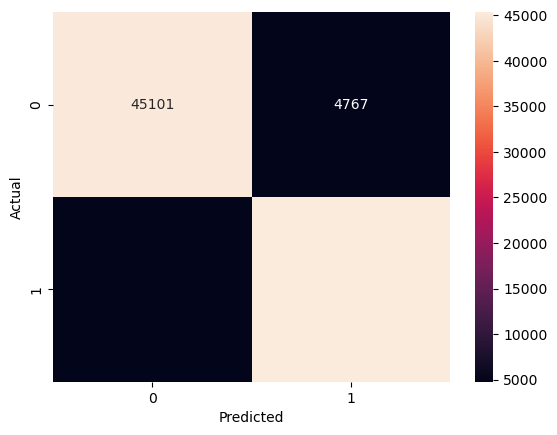

In [34]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()